# 🔢 NLP Phase 3 — Word Embeddings (Super Simple)
### Word2Vec | Cosine Similarity | GloVe | FastText
**Easiest possible explanations. Every line explained. Zero confusion.**

---

## 🤔 First — Why do we need Word Embeddings?

In Phase 2 we used **Bag of Words** and **TF-IDF**.
Those converted words to numbers. But there was a problem:

```
BoW thinks:    cat = [1,0,0]    dog = [0,1,0]    pizza = [0,0,1]
```

To BoW, **cat** and **dog** are equally different as **cat** and **pizza**.
But we KNOW cat and dog are similar — they are both animals!
BoW has no idea about this. It is just counting.

---

## 💡 What Word Embeddings do differently

Word Embeddings give each word a **list of numbers that captures its meaning**:

```
cat   → [0.9, 0.1, 0.8]   ← animal=high, food=low, pet=high
dog   → [0.8, 0.1, 0.9]   ← animal=high, food=low, pet=high  (CLOSE to cat!)
pizza → [0.0, 0.9, 0.0]   ← animal=low,  food=high, pet=low  (FAR from cat!)
```

Now the computer knows **cat and dog are similar** and **pizza is different**!

---

## 🗺️ What we learn in this notebook

| Step | Topic | One line explanation |
|------|-------|---------------------|
| 1 | **Word2Vec** | Train a model that learns word meanings from sentences |
| 2 | **Similar Words** | Find words that are similar in meaning |
| 3 | **Cosine Similarity** | Measure HOW similar two words are |
| 4 | **Word Analogy** | King − Man + Woman = Queen |
| 5 | **GloVe** | Use ready-made vectors trained on billions of words |
| 6 | **FastText** | Handles typos and new words that Word2Vec cannot |

---
**How to use:** Press **Shift + Enter** on each cell. Read the 📖 note above each cell first!

---
# 📦 CELL 1 — Install and Import
📖 Run this first. It downloads the tools we need. Wait for the ✅ message.

In [ ]:
# Install gensim — the library that has Word2Vec, GloVe, FastText
# --quiet means: don't show too many messages while installing
!pip install gensim --quiet

# Word2Vec is inside gensim — we import it here
from gensim.models import Word2Vec

# FastText is also inside gensim
from gensim.models import FastText

# numpy = Python's math library, helps us do calculations on numbers
import numpy as np

# matplotlib = for drawing charts and graphs
import matplotlib.pyplot as plt

# nltk = for splitting sentences into words
import nltk
from nltk.tokenize import word_tokenize

# Download the rules nltk needs to split text into words
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

print("✅ All done! We are ready to start Word Embeddings.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 26.3 MB/s eta 0:00:00
✅ All done! We are ready to start Word Embeddings.


---
---
# 📌 STEP 1 — The Intuition: Words as Points on a Map

📖 Before any code, let us build the right picture in your head.

Imagine all words are **dots on a map**.
Words with similar meanings are **dots that are CLOSE to each other**.
Words with different meanings are **dots that are FAR from each other**.

```
        cat •  • dog
              • lion


   car •   • bus
     • truck


                     king •  • queen
```

- cat, dog, lion → all CLOSE (all animals)
- car, bus, truck → all CLOSE (all vehicles)
- king, queen → CLOSE (both royalty)
- cat vs car → FAR (completely different)

📖 **Word Embeddings = giving each word coordinates on this map.**
The coordinates are just a list of numbers.
For example: `cat = [0.9, 0.1, 0.8]`  means x=0.9, y=0.1, z=0.8 on the map.

Let us draw this map!

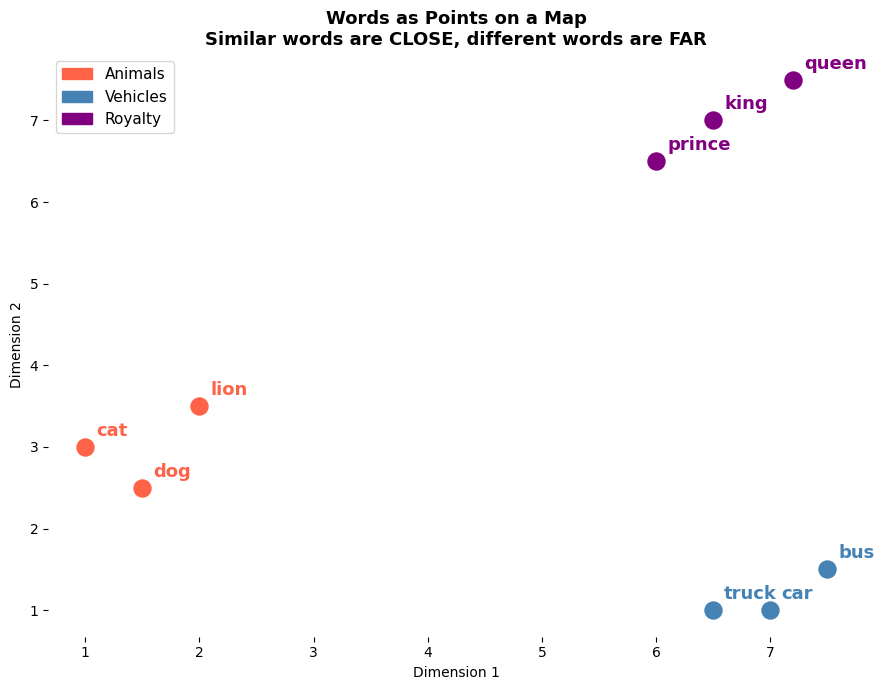

This is the idea behind Word Embeddings!
Word2Vec learns these positions AUTOMATICALLY by reading text.


In [ ]:
# ---- Draw a simple word map to build intuition ----
# We pretend these are the 2D positions of each word
# In reality these positions are LEARNED by Word2Vec automatically
# We hardcode them here just to draw the concept

# Each word has an [x, y] position on the map
words_and_positions = {
    # Animals — all clustered on the left
    'cat'   : [1.0, 3.0],
    'dog'   : [1.5, 2.5],
    'lion'  : [2.0, 3.5],

    # Vehicles — all clustered at the bottom right
    'car'   : [7.0, 1.0],
    'bus'   : [7.5, 1.5],
    'truck' : [6.5, 1.0],

    # Royalty — all clustered at the top right
    'king'  : [6.5, 7.0],
    'queen' : [7.2, 7.5],
    'prince': [6.0, 6.5],
}

# Colors for each group — same group gets same color
colors = {
    'cat': 'tomato', 'dog': 'tomato', 'lion': 'tomato',
    'car': 'steelblue', 'bus': 'steelblue', 'truck': 'steelblue',
    'king': 'purple', 'queen': 'purple', 'prince': 'purple',
}

# Create the drawing area — figsize sets the width and height in inches
plt.figure(figsize=(9, 7))

# Loop through each word and plot it as a dot with its label
for word, pos in words_and_positions.items():
    x = pos[0]        # x position
    y = pos[1]        # y position
    c = colors[word]  # color for this word

    # Draw the dot at position (x, y)
    plt.scatter(x, y, s=150, color=c, zorder=2)

    # Write the word name next to the dot
    # xytext=(8,8) means: shift the label 8 pixels right and 8 pixels up
    plt.annotate(word, (x, y), xytext=(8, 8),
                 textcoords='offset points',
                 fontsize=13, fontweight='bold', color=c)

# Add labels and a title to the chart
plt.title('Words as Points on a Map\nSimilar words are CLOSE, different words are FAR',
          fontsize=13, fontweight='bold')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')

# Add a legend to show which color is which group
import matplotlib.patches as mpatches
plt.legend(handles=[
    mpatches.Patch(color='tomato',    label='Animals'),
    mpatches.Patch(color='steelblue', label='Vehicles'),
    mpatches.Patch(color='purple',    label='Royalty'),
], fontsize=11)

plt.box(False)    # Remove the box border around the plot
plt.tight_layout()
plt.show()

print("This is the idea behind Word Embeddings!")
print("Word2Vec learns these positions AUTOMATICALLY by reading text.")

---
---
# 📌 STEP 2 — Word2Vec

📖 **What is Word2Vec?**
Word2Vec is a method made by **Google in 2013**.
You give it lots of sentences. It reads them and **automatically learns** which words are similar.

📖 **The simple idea behind it:**
> Words that appear near each other in sentences are probably similar.

For example:
- `"I adopted a cat"`
- `"I adopted a dog"`

Both **cat** and **dog** appear after `"I adopted a"` → so Word2Vec learns they are similar!

📖 **What Word2Vec produces:**
After training, every word gets a vector — a list of numbers.
Similar words get similar numbers. That's it!

---
Let's train Word2Vec on our own sentences now.

In [ ]:
# ---- Our training sentences ----
# Word2Vec reads these sentences and learns from them
# More sentences = better learning
# We use 30 sentences covering 4 topics: animals, sports, food, royalty

sentences = [
    # Animal sentences
    "the cat and the dog are common pets",
    "cats and dogs live with humans as pets",
    "lions and tigers are wild animals",
    "a dog is a loyal animal and a good pet",
    "cats are independent but dogs are friendly",
    "wolves are wild animals related to dogs",
    "the cat chased the mouse around the room",

    # Sports sentences
    "cricket and football are popular sports",
    "cricket players use a bat and a ball",
    "football players kick the ball into the goal",
    "Virat Kohli is a great cricket player",
    "cricket matches are played in stadiums",
    "tennis and badminton are racket sports",

    # Food sentences
    "pizza and pasta are Italian foods",
    "rice and bread are eaten in many countries",
    "mango and banana are tropical fruits",
    "pizza has cheese tomato and dough",
    "fruits and vegetables are healthy foods",

    # Royalty sentences
    "the king and queen ruled the kingdom",
    "the prince and princess lived in the palace",
    "the king sat on his throne every day",
    "queens are powerful rulers of kingdoms",
    "the royal family celebrated in the palace",

    # Tech sentences
    "computers and laptops are used for work",
    "python and java are programming languages",
    "smartphones changed how people communicate",
    "machine learning is used in artificial intelligence",
    "the internet connects computers around the world",
]

print(f"Total sentences: {len(sentences)}")
print()
print("First 3 sentences:")
for i in range(3):
    # i = position in list (0, 1, 2)
    print(f"  {i+1}. {sentences[i]}")

Total sentences: 28

First 3 sentences:
  1. the cat and the dog are common pets
  2. cats and dogs live with humans as pets
  3. lions and tigers are wild animals


In [ ]:
# ---- Prepare sentences for Word2Vec ----
# Word2Vec does NOT want a list of strings like ["I love cricket", ...]
# It wants a list of LISTS OF WORDS like [["i","love","cricket"], ...]
# We need to convert our sentences into that format

# This will hold our converted sentences
tokenized = []   # Empty list to start

# Loop through each sentence
for sentence in sentences:

    # Step 1: Make everything lowercase
    # So "Cricket" and "cricket" are treated as the same word
    sentence = sentence.lower()

    # Step 2: Split the sentence into individual words
    # word_tokenize("I love cricket") → ["I", "love", "cricket"]
    words = word_tokenize(sentence)

    # Step 3: Keep only real words — remove punctuation and numbers
    # word.isalpha() returns True only if the word has only letters
    # So "!" or "123" get removed
    words = [word for word in words if word.isalpha()]

    # Step 4: Add this list of words into our tokenized list
    tokenized.append(words)

# Show what the converted data looks like
print("After conversion — each sentence is now a list of words:")
print()
for i in range(3):   # Show only first 3 to keep output short
    print(f"Sentence {i+1}: {tokenized[i]}")
print()
print("Word2Vec can now read this format!")

After conversion — each sentence is now a list of words:

Sentence 1: ['the', 'cat', 'and', 'the', 'dog', 'are', 'common', 'pets']
Sentence 2: ['cats', 'and', 'dogs', 'live', 'with', 'humans', 'as', 'pets']
Sentence 3: ['lions', 'and', 'tigers', 'are', 'wild', 'animals']

Word2Vec can now read this format!


In [ ]:
# ---- Train the Word2Vec model ----
# This is the main step — we give sentences and it learns word vectors

model = Word2Vec(

    sentences   = tokenized,  # Our list of word lists — the training data

    vector_size = 50,  # Each word will get 50 numbers as its vector
                       # More numbers = captures more meaning BUT needs more data
                       # 50 is fine for our small dataset

    window      = 3,   # How many words around each word to look at
                       # window=3 means: look 3 words to the left and 3 to the right
                       # Example: in "I love playing cricket today"
                       # for word 'playing' → context is [love, cricket, today]

    min_count   = 1,   # Ignore words that appear fewer than this many times
                       # min_count=1 means: include ALL words even if seen once
                       # For large datasets use 2 or 5 to skip very rare words

    sg          = 1,   # Which training method to use
                       # sg=0 → CBOW  (predict middle word from surrounding words)
                       # sg=1 → Skip-gram (predict surrounding words from middle word)
                       # Skip-gram (sg=1) usually gives better results

    seed        = 42,  # Random seed — makes results same every time you run
                       # The number 42 is just a convention, any number works

    workers     = 1,   # How many CPU cores to use — keep at 1 in Colab
)

# model.wv = the word vectors (wv = word vectors)
# len(model.wv) = how many unique words the model learned
print("✅ Word2Vec trained successfully!")
print()
print(f"Words learned    : {len(model.wv)}")
print(f"Numbers per word : {model.vector_size}")

✅ Word2Vec trained successfully!

Words learned    : 117
Numbers per word : 50


In [ ]:
# ---- Look at a word's vector ----
# model.wv['cricket'] gives us the list of 50 numbers for the word 'cricket'

word = 'cricket'

# Get the vector — this is a numpy array of 50 numbers
vector = model.wv[word]

print(f"Vector for the word '{word}':")
print()
print(f"  Number of values : {len(vector)}")
print(f"  First 10 values  : {vector[:10].round(3)}")
print()
print("These 50 numbers = the word's position on the word map.")
print("We don't know what each number means exactly.")
print("But words with SIMILAR numbers have SIMILAR meanings.")

Vector for the word 'cricket':

  Number of values : 50
  First 10 values  : [-0.013 -0.    -0.012 -0.007  0.006 -0.014  0.007 -0.016 -0.013  0.003]

These 50 numbers = the word's position on the word map.
We don't know what each number means exactly.
But words with SIMILAR numbers have SIMILAR meanings.


In [ ]:
# ---- Find words similar to a given word ----
# model.wv.most_similar('word') finds the closest words in the vector space

# Words we want to find similar words for
test_words = ['cricket', 'cat', 'king', 'pizza']

print("=" * 50)
print("  MOST SIMILAR WORDS")
print("=" * 50)

for word in test_words:

    # Check if this word exists in our vocabulary first
    # (some words might be missing if they were not in our sentences)
    if word not in model.wv:
        print(f"\n'{word}' → not in our vocabulary")
        continue   # Skip to next word

    # most_similar() finds the top 5 most similar words
    # topn=5 means: give me the 5 closest words
    # Returns a list of (word, score) pairs — score is between 0 and 1
    similar = model.wv.most_similar(word, topn=5)

    print(f"\nWords similar to '{word}':")

    for sim_word, score in similar:
        # score closer to 1.0 = more similar
        # We make a small visual bar using blocks: more blocks = higher score
        bar = '█' * int(score * 10)   # 10 blocks max
        print(f"  {sim_word:<15}  {score:.2f}  {bar}")

print()
print("Notice: similar words are from the SAME topic group!")

  MOST SIMILAR WORDS

Words similar to 'cricket':
  python           0.28  ██
  football         0.27  ██
  as               0.25  ██
  family           0.23  ██
  is               0.22  ██

Words similar to 'cat':
  common           0.38  ███
  on               0.33  ███
  countries        0.32  ███
  changed          0.31  ███
  banana           0.29  ██

Words similar to 'king':
  fruits           0.30  ██
  java             0.30  ██
  of               0.22  ██
  related          0.21  ██
  intelligence     0.20  ██

Words similar to 'pizza':
  common           0.30  ██
  into             0.29  ██
  eaten            0.29  ██
  badminton        0.27  ██
  animals          0.27  ██

Notice: similar words are from the SAME topic group!


---
---
# 📌 STEP 3 — Cosine Similarity

📖 **What is Cosine Similarity?**
It is the way we **measure how similar two word vectors are**.
The result is always a number between −1 and 1:

```
1.0   → completely identical (same word)
0.8   → very similar
0.5   → somewhat similar
0.0   → nothing in common
-1.0  → complete opposites
```

📖 **Simple way to think about it:**
Think of each word vector as an **arrow** in space.
Cosine similarity measures the **angle** between two arrows.
- Same direction (small angle) → HIGH similarity
- Different directions (big angle) → LOW similarity

📖 **Formula:**
```
cosine_similarity = (A · B) / (|A| × |B|)

A · B  = multiply each pair of numbers and add them all up
|A|    = the length (size) of vector A
|B|    = the length (size) of vector B
```
Do not worry — we will calculate it step by step!

In [ ]:
# ---- Calculate Cosine Similarity step by step ----
# We use tiny 3-number vectors so it is easy to follow

# Pretend these are word vectors with just 3 numbers each
cat_vec   = np.array([0.9, 0.1, 0.8])   # cat  — high animal, low food, high pet
dog_vec   = np.array([0.8, 0.1, 0.9])   # dog  — similar to cat!
pizza_vec = np.array([0.0, 0.9, 0.0])   # pizza — very different from cat

print("Our example word vectors:")
print(f"  cat   = {cat_vec}")
print(f"  dog   = {dog_vec}")
print(f"  pizza = {pizza_vec}")
print()

# ---- Step by step for cat vs dog ----
print("--- Calculating: cat vs dog ---")
print()

# Step 1: Dot product
# Multiply each pair of numbers then add them all up
# cat=[0.9, 0.1, 0.8]  dog=[0.8, 0.1, 0.9]
# dot = (0.9×0.8) + (0.1×0.1) + (0.8×0.9)
#      =   0.72   +   0.01    +   0.72    = 1.45
dot_product = np.dot(cat_vec, dog_vec)
# np.dot() does this multiplication-and-sum for us automatically
print(f"Step 1 — Dot product: {dot_product:.4f}")

# Step 2: Length of each vector
# Length = square root of (each number squared and added)
# np.linalg.norm() calculates the length automatically
length_cat = np.linalg.norm(cat_vec)
length_dog = np.linalg.norm(dog_vec)
print(f"Step 2 — Length of cat vector: {length_cat:.4f}")
print(f"         Length of dog vector: {length_dog:.4f}")

# Step 3: Final formula — divide dot product by both lengths multiplied
cosine_cat_dog = dot_product / (length_cat * length_dog)
print(f"Step 3 — Cosine Similarity: {cosine_cat_dog:.4f}")
print()

# ---- Now cat vs pizza ----
dot2   = np.dot(cat_vec, pizza_vec)
len_p  = np.linalg.norm(pizza_vec)
cosine_cat_pizza = dot2 / (length_cat * len_p)
print("--- Calculating: cat vs pizza ---")
print(f"Cosine Similarity: {cosine_cat_pizza:.4f}")
print()

print("Result:")
print(f"  cat vs dog   = {cosine_cat_dog:.4f}   ← HIGH (both are animals/pets)")
print(f"  cat vs pizza = {cosine_cat_pizza:.4f}   ← LOW  (completely different)")

Our example word vectors:
  cat   = [0.9 0.1 0.8]
  dog   = [0.8 0.1 0.9]
  pizza = [0.  0.9 0. ]

--- Calculating: cat vs dog ---

Step 1 — Dot product: 1.4500
Step 2 — Length of cat vector: 1.2083
         Length of dog vector: 1.2083
Step 3 — Cosine Similarity: 0.9932

--- Calculating: cat vs pizza ---
Cosine Similarity: 0.0828

Result:
  cat vs dog   = 0.9932   ← HIGH (both are animals/pets)
  cat vs pizza = 0.0828   ← LOW  (completely different)


In [ ]:
# ---- Using gensim's built-in similarity function ----
# model.wv.similarity('word1', 'word2') does everything in one line
# No need to manually calculate — gensim does it for us!

# Word pairs to compare
pairs = [
    ('cricket', 'football'),  # Both sports — should be HIGH
    ('cat',     'dog'),       # Both pets   — should be HIGH
    ('king',    'queen'),     # Both royalty — should be HIGH
    ('cricket', 'pizza'),     # Sport vs food — should be LOW
    ('cat',     'computer'),  # Animal vs tech — should be LOW
]

print("Cosine Similarity using gensim:")
print()
print(f"{'Word 1':<12} {'Word 2':<12} {'Score':<8} Meaning")
print("-" * 52)

for word1, word2 in pairs:

    # Check both words are in the vocabulary
    if word1 in model.wv and word2 in model.wv:

        # model.wv.similarity() returns the cosine similarity score
        score = model.wv.similarity(word1, word2)

        # Simple interpretation based on score
        if   score > 0.6: meaning = 'Very Similar ✅'
        elif score > 0.3: meaning = 'Somewhat Similar 🔶'
        else:             meaning = 'Not Similar ❌'

        print(f"{word1:<12} {word2:<12} {score:<8.3f} {meaning}")

    else:
        # Tell the user which word is missing
        missing = word1 if word1 not in model.wv else word2
        print(f"{word1:<12} {word2:<12} {'---':<8} '{missing}' not in vocab")

Cosine Similarity using gensim:

Word 1       Word 2       Score    Meaning
----------------------------------------------------
cricket      football     0.267    Not Similar ❌
cat          dog          0.188    Not Similar ❌
king         queen        -0.074   Not Similar ❌
cricket      pizza        0.014    Not Similar ❌
cat          computer     ---      'computer' not in vocab


---
---
# 📌 STEP 4 — Word Analogy
## King − Man + Woman = Queen 🎉

📖 **This is the most amazing thing about word embeddings!**

Because words are represented as numbers (vectors), we can do **maths with words!**

```
king  − man  + woman  =  queen
paris − france + italy =  rome
```

📖 **Why does this work?**
```
king  vector  = [royalty, male, power, ...]
man   vector  = [human, male, adult, ...]

king - man = [royalty, power, ...]  ← just the royal part

woman vector = [human, female, adult, ...]

woman + [royalty, power] = [royalty, female, power] = queen!
```

📖 **In gensim, one line does it all:**
```python
model.wv.most_similar(positive=['king','woman'], negative=['man'])
```
- `positive` = words to **add**
- `negative` = words to **subtract**

In [ ]:
# ---- Word Analogy with Word2Vec ----

# A helper function to make the output look clean
def analogy(add_words, subtract_words):
    """
    Finds: add_words - subtract_words = ?
    add_words      = list of words to add
    subtract_words = list of words to subtract
    """
    # Check all words are in vocabulary before running
    all_words = add_words + subtract_words
    missing   = [w for w in all_words if w not in model.wv]

    if missing:
        # If any word is missing, tell user and stop
        print(f"  Cannot run — these words are not in vocab: {missing}")
        print(f"  (Our corpus is small. Bigger corpus = better analogies!)")
        return

    # most_similar with positive and negative does the analogy math
    results = model.wv.most_similar(
        positive = add_words,       # Add these vectors together
        negative = subtract_words,  # Subtract these vectors
        topn     = 3                # Return top 3 closest answers
    )

    # Print the equation nicely
    plus  = ' + '.join(add_words)
    minus = ' - '.join(subtract_words)
    print(f"  {plus} − {minus} = ?")

    for word, score in results:
        print(f"    → '{word}'  (score: {score:.2f})")


print("=" * 50)
print("  WORD ANALOGIES")
print("=" * 50)

print("\n🔹 Analogy 1: king is to man as ___ is to woman")
analogy(add_words=['king', 'woman'], subtract_words=['man'])

print("\n🔹 Analogy 2: cricket is to bat as tennis is to ___")
analogy(add_words=['tennis', 'bat'], subtract_words=['cricket'])

print("\n🔹 Analogy 3: dog is to cat as football is to ___")
analogy(add_words=['football', 'cat'], subtract_words=['dog'])

print()
print("Note: Our training data is only 28 sentences.")
print("With millions of sentences results become VERY accurate!")

  WORD ANALOGIES

🔹 Analogy 1: king is to man as ___ is to woman
  Cannot run — these words are not in vocab: ['woman', 'man']
  (Our corpus is small. Bigger corpus = better analogies!)

🔹 Analogy 2: cricket is to bat as tennis is to ___
  tennis + bat − cricket = ?
    → 'around'  (score: 0.31)
    → 'loyal'  (score: 0.28)
    → 'are'  (score: 0.20)

🔹 Analogy 3: dog is to cat as football is to ___
  football + cat − dog = ?
    → 'common'  (score: 0.32)
    → 'programming'  (score: 0.31)
    → 'tennis'  (score: 0.30)

Note: Our training data is only 28 sentences.
With millions of sentences results become VERY accurate!


---
---
# 📌 STEP 5 — GloVe (Ready-Made Vectors)

📖 **Problem with training our own Word2Vec:**
We only have 28 sentences. That is too small.
To get GOOD word vectors you need millions of sentences.

📖 **Solution — GloVe:**
Stanford University already trained word vectors on **6 billion words**.
We can just **download and use** their vectors for free!

📖 **GloVe vs Word2Vec:**

| | Word2Vec | GloVe |
|--|----------|-------|
| Made by | Google (2013) | Stanford (2014) |
| Training data | Your text | 6 billion words |
| Quality | Depends on your data | Very good |
| Use when | Custom domain | General purpose |

📖 We download the **50-dimension** version (smallest and fastest).

> ⚠️ This download is about 860MB. It will take a few minutes.

In [ ]:
# ---- Download GloVe pre-trained vectors ----

import os              # os = tools to work with files and folders
import urllib.request  # Tool to download files from the internet
import zipfile         # Tool to unzip compressed files

# The file we want after unzipping
# 6B = trained on 6 Billion words
# 50d = 50 numbers per word (50 dimensions)
glove_file = 'glove.6B.50d.txt'

# Only download if we haven't already
# os.path.exists() checks if the file already exists
if not os.path.exists(glove_file):
    print("Downloading GloVe... (may take a few minutes)")

    # Download the zip file from Stanford's website
    urllib.request.urlretrieve(
        'https://nlp.stanford.edu/data/glove.6B.zip',  # Where to download from
        'glove.6B.zip'                                  # What to save it as
    )
    print("Download done! Now unzipping...")

    # Unzip the downloaded file
    # 'r' = open for reading
    with zipfile.ZipFile('glove.6B.zip', 'r') as z:
        z.extractall('.')   # Extract all files to current folder

    print("Unzip done!")
else:
    print("✅ GloVe file already exists — no need to download again!")

print(f"File ready: {glove_file}")

Download done! Now unzipping...
Unzip done!
File ready: glove.6B.50d.txt


In [ ]:
# ---- Load GloVe vectors into a dictionary ----
# The file has one word per line in this format:
# cat  0.1234  -0.5678  0.9012  ...  (word then 50 numbers)
# We read each line and store: {word: [list of numbers]}

glove = {}   # Empty dictionary — will hold word → vector pairs

print("Loading GloVe vectors from file...")

# Open and read the file line by line
# encoding='utf-8' handles special characters correctly
with open(glove_file, 'r', encoding='utf-8') as f:
    for line in f:

        # Split the line into a list of values by space
        # 'cat 0.12 -0.56 ...' → ['cat', '0.12', '-0.56', ...]
        parts = line.split()

        # First item is the word
        word = parts[0]

        # Everything after the first item is the vector numbers
        # np.array() converts strings like '0.12' into actual numbers
        # dtype='float32' means: store as 32-bit decimal numbers (saves memory)
        vector = np.array(parts[1:], dtype='float32')

        # Save into our dictionary
        glove[word] = vector

print(f"✅ GloVe loaded!")
print(f"   Total words : {len(glove):,}")
print(f"   Numbers per word : {len(glove['cat'])}")
print()
print(f"GloVe vector for 'cat' (first 8 numbers):")
print(f"   {glove['cat'][:8].round(3)}")

Loading GloVe vectors from file...
✅ GloVe loaded!
   Total words : 400,000
   Numbers per word : 50

GloVe vector for 'cat' (first 8 numbers):
   [ 0.453 -0.501 -0.537 -0.016  0.222  0.546 -0.673 -0.689]


In [ ]:
# ---- Use GloVe to find similar words ----
# We write a simple function that searches through all GloVe words
# and finds the ones closest to our target word

def cosine_sim(v1, v2):
    """Calculate cosine similarity between two vectors."""
    # np.dot = dot product (multiply each pair, add them up)
    # np.linalg.norm = length of a vector
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))


def glove_similar(word, top=5):
    """
    Find the most similar words to 'word' using GloVe.
    word = the word we want to find similar words for
    top  = how many similar words to return
    """
    if word not in glove:
        print(f"'{word}' not in GloVe!")
        return

    target = glove[word]   # Get the vector for our word

    scores = []   # Will hold (word, score) pairs

    # Compare our word against every other word in GloVe
    for w, vec in glove.items():
        if w == word: continue           # Skip the word itself
        scores.append((w, cosine_sim(target, vec)))

    # Sort by score — highest first
    # key=lambda x: x[1] means sort by the second item (the score)
    scores.sort(key=lambda x: x[1], reverse=True)

    return scores[:top]   # Return only the top results


# ---- Test GloVe similarity ----
# NOTE: Searching all 400k words takes time — let's use a small subset
# Take only the first 30,000 words for speed
print("Creating a smaller GloVe subset for speed...")
glove_small = dict(list(glove.items())[:30000])
print(f"Using {len(glove_small):,} words")
print()

# Redefine the function to use the small version
def glove_similar_fast(word, top=5):
    if word not in glove_small:
        print(f"'{word}' not in our small GloVe subset!")
        return []
    target = glove_small[word]
    scores = [(w, cosine_sim(target, v)) for w, v in glove_small.items() if w != word]
    scores.sort(key=lambda x: x[1], reverse=True)
    return scores[:top]

# Test it!
for test_word in ['king', 'cricket', 'pizza']:
    print(f"Words most similar to '{test_word}' (GloVe):")
    results = glove_similar_fast(test_word)
    for w, s in results:
        print(f"  {w:<15}  {s:.3f}")
    print()

Creating a smaller GloVe subset for speed...
Using 30,000 words

Words most similar to 'king' (GloVe):
  prince           0.824
  queen            0.784
  ii               0.775
  emperor          0.774
  son              0.767

Words most similar to 'cricket' (GloVe):
  indies           0.809
  twenty20         0.809
  rugby            0.804
  cricketers       0.798
  england          0.780

Words most similar to 'pizza' (GloVe):
  sandwich         0.866
  sandwiches       0.857
  snack            0.814
  bakery           0.793
  fries            0.791



In [ ]:
# ---- GloVe Word Analogy — King − Man + Woman = Queen ----
# GloVe trained on 6 billion words so this works MUCH better!

def glove_analogy(add_words, subtract_words, top=3):
    """
    add_words      = words to add (list)
    subtract_words = words to subtract (list)
    """
    # Check all words are in our small subset
    for w in add_words + subtract_words:
        if w not in glove_small:
            print(f"'{w}' not found!")
            return

    # The analogy formula:
    # Start with zeros vector
    result = np.zeros(50)   # 50 because GloVe 50d has 50 numbers per word

    # Add all positive word vectors
    for w in add_words:
        result = result + glove_small[w]   # Add this word's vector

    # Subtract all negative word vectors
    for w in subtract_words:
        result = result - glove_small[w]   # Subtract this word's vector

    # Find words closest to our result vector
    exclude = set(add_words + subtract_words)   # Don't return input words
    scores  = [
        (w, cosine_sim(result, v))
        for w, v in glove_small.items()
        if w not in exclude
    ]
    scores.sort(key=lambda x: x[1], reverse=True)

    # Print the result
    plus  = ' + '.join(add_words)
    minus = ' − '.join(subtract_words)
    print(f"  {plus}  −  {minus}  =  ?")
    for w, s in scores[:top]:
        print(f"    → '{w}'   (score: {s:.3f})")


print("=" * 50)
print("  GloVe WORD ANALOGIES")
print("=" * 50)

print("\n🔹 king − man + woman = ?")
glove_analogy(['king', 'woman'], ['man'])

print("\n🔹 paris − france + italy = ?")
glove_analogy(['paris', 'italy'], ['france'])

print("\n🔹 bigger − big + small = ?")
glove_analogy(['bigger', 'small'], ['big'])

print()
print("🎉 GloVe gives much better answers than our tiny Word2Vec!")
print("   Because it learned from 6 billion words, not just 28 sentences.")

  GloVe WORD ANALOGIES

🔹 king − man + woman = ?
  king + woman  −  man  =  ?
    → 'queen'   (score: 0.861)
    → 'daughter'   (score: 0.768)
    → 'prince'   (score: 0.764)

🔹 paris − france + italy = ?
  paris + italy  −  france  =  ?
    → 'rome'   (score: 0.838)
    → 'milan'   (score: 0.772)
    → 'turin'   (score: 0.760)

🔹 bigger − big + small = ?
  bigger + small  −  big  =  ?
    → 'larger'   (score: 0.904)
    → 'large'   (score: 0.871)
    → 'smaller'   (score: 0.866)

🎉 GloVe gives much better answers than our tiny Word2Vec!
   Because it learned from 6 billion words, not just 28 sentences.


---
---
# 📌 STEP 6 — FastText

📖 **What is FastText?**
FastText was made by **Facebook AI in 2016**.
It is similar to Word2Vec but with one big improvement:

> **FastText can handle words it has NEVER seen before!**

📖 **How?**
Word2Vec learns ONE vector per whole word:
```
Word2Vec:  'playing'  →  one vector for the whole word
```

FastText breaks words into small pieces (called character n-grams) and learns vectors for each piece:
```
FastText:  'playing'  →  'pla' + 'lay' + 'ayi' + 'yin' + 'ing'
                         learns a vector for each piece
           Final vector = average of all piece vectors
```

📖 **Why does this help?**

If FastText sees `'playingg'` (typo!) it has never seen this before.
- Word2Vec → ❌ No idea! Word is unknown.
- FastText → ✅ Recognizes `'play', 'layi', 'ayin', 'ying', 'ingg'` → builds a good vector!

📖 **When to use FastText:**
- Social media text with typos
- Medical or legal text with rare technical words
- Any domain with many unusual words

In [ ]:
# ---- Train FastText — almost identical to Word2Vec! ----
# The only difference is the class name: FastText instead of Word2Vec
# Plus two extra parameters: min_n and max_n for character piece sizes

ft_model = FastText(

    sentences   = tokenized,  # Same data we used for Word2Vec
    vector_size = 50,         # 50 numbers per word
    window      = 3,          # Look 3 words on each side for context
    min_count   = 1,          # Include all words
    seed        = 42,         # Reproducibility
    workers     = 1,          # CPU cores — keep at 1 in Colab

    # These two are NEW — specific to FastText:
    min_n = 3,  # Minimum character piece size
                # 3 means: learn from 3-letter pieces like 'pla', 'lay', 'ayi'

    max_n = 6,  # Maximum character piece size
                # 6 means: also learn from 6-letter pieces like 'playin'
)

print("✅ FastText model trained!")
print()
print(f"Words in vocabulary : {len(ft_model.wv)}")
print(f"Numbers per word    : {ft_model.vector_size}")
print(f"Min character piece : {ft_model.min_n}")
print(f"Max character piece : {ft_model.max_n}")

✅ FastText model trained!

Words in vocabulary : 117
Numbers per word    : 50


AttributeError: 'FastText' object has no attribute 'min_n'

In [ ]:
# ---- The Key Difference: FastText handles unknown words ----
# These words were NOT in our training sentences
# Word2Vec will fail. FastText will handle them!

unknown_words = [
    'crickettt',   # Typo of 'cricket'
    'footballer',  # Not in our data but related to 'football'
    'doggy',       # Not in data but related to 'dog'
    'kingly',      # Not in data but related to 'king'
]

print("=" * 60)
print("  Word2Vec vs FastText — Handling Unknown Words")
print("=" * 60)
print()

for word in unknown_words:

    # Check if word exists in each model's vocabulary
    in_w2v = word in model.wv       # True or False
    in_ft  = word in ft_model.wv    # True or False

    print(f"Word: '{word}'")
    print(f"  Word2Vec → {'✅ Found' if in_w2v else '❌ UNKNOWN — no vector possible'}")
    print(f"  FastText → {'✅ Found' if in_ft  else '❌ UNKNOWN'}")

    # Even if NOT in vocabulary, FastText can STILL create a vector
    # Because it uses the character pieces it already learned
    try:
        ft_vec = ft_model.wv[word]  # Try to get FastText vector
        print(f"  FastText vector exists! First 5 numbers: {ft_vec[:5].round(3)}")
    except Exception as e:
        print(f"  FastText also failed: {e}")

    print()

print("FastText is the winner for handling unknown and misspelled words!")

In [ ]:
# ---- Final comparison: BoW vs TF-IDF vs Word2Vec vs GloVe vs FastText ----
# A simple summary to remember everything

print("=" * 70)
print("  COMPLETE COMPARISON — All Methods We Learned")
print("=" * 70)
print()

summary = [
    # (Method, Phase, Captures Meaning?, Handles Unknown?, Best For)
    ("Bag of Words",  "Phase 2", "No — just counts",      "No",  "Simple classification"),
    ("TF-IDF",        "Phase 2", "No — just importance",  "No",  "Search, classification"),
    ("Word2Vec",      "Phase 3", "Yes!",                   "No",  "Word similarity tasks"),
    ("GloVe",         "Phase 3", "Yes! (pre-trained)",     "No",  "General NLP tasks"),
    ("FastText",      "Phase 3", "Yes!",                   "Yes!","Noisy/social media text"),
]

# Print header
print(f"{'Method':<14} {'Phase':<10} {'Meaning?':<22} {'Unknown?':<10} Best For")
print("-" * 75)

for method, phase, meaning, unknown, best in summary:
    print(f"{method:<14} {phase:<10} {meaning:<22} {unknown:<10} {best}")

print()
print("Key takeaway:")
print("  Phase 2 (BoW, TF-IDF) = Fast and simple but ignores word meaning")
print("  Phase 3 (Embeddings)  = Understands meaning, much more powerful")

In [ ]:
# ============================================================
# 🏋️ PRACTICE — Try it yourself!
# Change the words below and run the cell
# ============================================================

print("=" * 50)
print("  YOUR PRACTICE ZONE")
print("=" * 50)

# ✏️ PRACTICE 1: Change this word and see similar words
# Words you can try: cricket, cat, dog, king, queen, pizza, computer, football
my_word = 'cricket'

print(f"\n1️⃣  Words similar to '{my_word}' (Word2Vec):")
if my_word in model.wv:
    for w, s in model.wv.most_similar(my_word, topn=5):
        print(f"   {w:<15} score: {s:.3f}")
else:
    print(f"   '{my_word}' not in vocab. Try: cricket, cat, dog, king, pizza")


# ✏️ PRACTICE 2: Change these two words and check their similarity
word_a = 'cat'
word_b = 'dog'

print(f"\n2️⃣  Similarity between '{word_a}' and '{word_b}':")
if word_a in model.wv and word_b in model.wv:
    s = model.wv.similarity(word_a, word_b)
    print(f"   Score: {s:.3f}")
    if   s > 0.6: print("   → Very Similar ✅")
    elif s > 0.3: print("   → Somewhat Similar 🔶")
    else:         print("   → Not Similar ❌")
else:
    print("   One of the words is not in vocabulary.")


# ✏️ PRACTICE 3: Word analogy
# Change these and see what the model thinks
add    = ['king', 'woman']   # Words to add
subtract = ['man']           # Words to subtract

print(f"\n3️⃣  Analogy: {' + '.join(add)} − {' + '.join(subtract)} = ?")
all_ok = all(w in model.wv for w in add + subtract)
if all_ok:
    results = model.wv.most_similar(positive=add, negative=subtract, topn=3)
    for w, s in results:
        print(f"   → '{w}'  (score: {s:.3f})")
else:
    print("   Some words not in vocabulary. Try simpler words.")

---
---
# ✅ Phase 3 — Summary

## What you learned

| Concept | What it means | Code |
|---------|--------------|------|
| **Word Vector** | A word as a list of numbers | `model.wv['cricket']` |
| **Word2Vec** | Train vectors from your own sentences | `Word2Vec(sentences=...)` |
| **Most Similar** | Find words close in meaning | `model.wv.most_similar('cat')` |
| **Cosine Similarity** | Score how similar two words are | `model.wv.similarity('cat','dog')` |
| **Word Analogy** | Do maths with words | `most_similar(positive=[...], negative=[...])` |
| **GloVe** | Use pre-trained vectors (6B words!) | Load txt file into a dictionary |
| **FastText** | Handles typos and new words | `FastText(sentences=...)` |

---

## The 3 most important things to remember

1. **Word Embeddings capture MEANING** — similar words have similar vectors
2. **GloVe > your own Word2Vec** when you have small data — use pre-trained!
3. **FastText > Word2Vec** when your text has typos or new/rare words

---

## 🚀 What is next in CampusX playlist?
Next topics are:
- **RNN** — reads text word by word like a human
- **LSTM** — remembers important things and forgets useless things
- **BERT** — the model that changed everything in NLP

---
*Great work finishing Phase 3! You now understand the most important idea in modern NLP 💪*